In [93]:
import requests
import numpy as np
import json
import pickle
import pandas as pd
from datetime import datetime, timedelta
import sklearn
end_date = datetime(2024, 6, 1)
start_date = end_date - timedelta(days=6000)

# Design

Try with index fund

# Additional Possible Features if time allows it
look into : https://www.investopedia.com/top-7-technical-analysis-tools-4773275

In [94]:
API_KEY = "wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4"

ticker = "SPY"

url_hist_stock_price = f"https://financialmodelingprep.com/stable/historical-price-eod/full?symbol={ticker}&from={start_date.date()}&to={end_date.date()}&apikey={API_KEY}"

# Historical Data Request
response_hist_stock_price = requests.get(url_hist_stock_price)

json_response_hist_stock_price = response_hist_stock_price.json()

df_stock_hist = pd.DataFrame(json_response_hist_stock_price)

df_stock_hist['date'] = pd.to_datetime(df_stock_hist['date'])
df_stock_hist['close'] = df_stock_hist['close'].astype(float)
df_stock_hist['open'] = df_stock_hist['open'].astype(float)
df_stock_hist['high'] = df_stock_hist['high'].astype(float)
df_stock_hist['low'] = df_stock_hist['low'].astype(float)


df_stock_hist.set_index('date', inplace=True)
df_stock_hist.drop(columns=['symbol'])

closing_price = df_stock_hist[['close']]
closing_price = closing_price.sort_index(ascending=True)

# AD LINE
denominator = df_stock_hist['high'] - df_stock_hist['low']
denominator = denominator.replace(0, np.nan)

# RESEARCH A BIT MORE
mfm = ((df_stock_hist['close'] - df_stock_hist['low']) - (df_stock_hist['high'] - df_stock_hist['close'])) / denominator
mfv_series = mfm * df_stock_hist['volume']
mfv = mfv_series.fillna(0)
mfv = mfv.to_frame(name="MFV")
ad_line = mfv['MFV'].cumsum().to_frame()
ad_line = ad_line.sort_index(ascending=True)
i_volume = df_stock_hist[['volume']]
i_volume = i_volume.sort_index(ascending=True)
volume =i_volume.apply(np.log10)


              ret_1d    ret_5d   ret_10d    vol_5d   vol_10d  momentum_10d  \
date                                                                         
2008-03-12 -0.009351 -0.018456 -0.049631  0.022577  0.016611         -6.86   
2008-03-13  0.002208  0.004502 -0.038138  0.022502  0.016647         -5.22   
2008-03-14 -0.015496 -0.000771 -0.031460  0.020360  0.016693         -4.21   
2008-03-17 -0.010107  0.002344 -0.038951  0.021200  0.015978         -5.20   
2008-03-18  0.041543  0.007768  0.004812  0.020761  0.016127          0.64   
2008-03-19 -0.024770 -0.007917 -0.026227  0.023157  0.021591         -3.51   
2008-03-20  0.013505  0.003266  0.007783  0.025874  0.022889          1.02   
2008-03-24  0.019988  0.039426  0.038625  0.026738  0.022405          5.01   
2008-03-25  0.000965  0.051052  0.053516  0.025985  0.022752          6.85   
2008-03-26 -0.012236 -0.003218  0.004525  0.024481  0.021990          0.60   
2008-03-27 -0.003153  0.018877  0.010810  0.018336  0.019728   

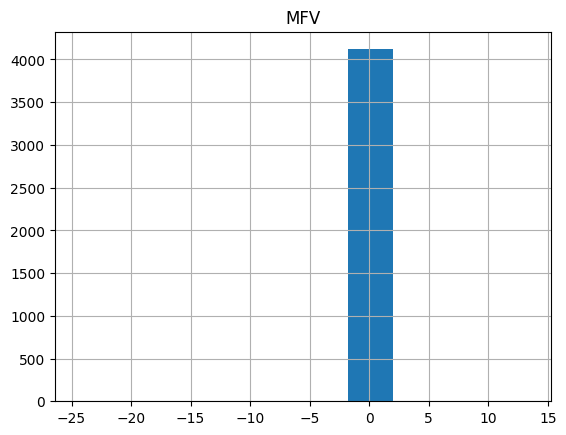

In [95]:
# Daily Return
daily_return = closing_price.pct_change()
# 5-Day Return
ret_5d = closing_price.pct_change(5)
# 10-Day Return
ret_10d = closing_price.pct_change(10)

# 5-Day Volatility (Std Dev of Returns)
vol_5d = closing_price.pct_change().shift(1).rolling(window=5).std()

# 10-Day Volatility
vol_10d = closing_price.pct_change().shift(1).rolling(window=10).std()

# Momentum (10d)
momentum_10d = closing_price - closing_price.shift(10)

AD_momentum_5d = ad_line.pct_change(5)
AD_momentum_10d = ad_line.pct_change(10)
AD_momentum_20d = ad_line.pct_change(20)
# SMA_10/SMA_50 Ratio
sma_10 = closing_price.shift(1).rolling(window=10).mean()
sma_50 = closing_price.shift(1).rolling(window=50).mean()
sma_ratio = sma_10/sma_50

# Z-score (20d)
rolling_mean = closing_price.shift(1).rolling(window=20).mean()
rolling_std = closing_price.shift(1).rolling(window=20).std()
z_score_20d = (closing_price - rolling_mean)/rolling_std

# RSI (14d)
delta = closing_price.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.shift(1).rolling(window=14).mean()
avg_loss = loss.shift(1).rolling(window=14).mean()

rs = avg_gain/avg_loss
rsi_14 = 100 - (100 / (1 + rs))

y = closing_price.pct_change(-30)

avrg = y.mean()

y.columns = ['y']


dataframes = [
    (daily_return, 'ret_1d'),
    (ret_5d, 'ret_5d'),
    (ret_10d, 'ret_10d'),
    (vol_5d, 'vol_5d'),
    (vol_10d, 'vol_10d'),
    (momentum_10d, 'momentum_10d'),
    (sma_ratio, 'sma_ratio_10_50'),
    (z_score_20d, 'zscore_20d'),
    (rsi_14, 'rsi_14'),
    (volume,'volume'),
    (AD_momentum_5d,'AD_momentum_5d'),
    (AD_momentum_10d,'AD_momentum_10d'),
    (AD_momentum_20d,'AD_momentum_20d'),
    (y,'y'),
]
AD_momentum_5d.hist()
print()
df_features_short_term = pd.concat(
    [df.rename(columns={df.columns[0]: name}) for df, name in dataframes],
    axis=1
).dropna()

print(df_features_short_term)

In [96]:
print(y.max())

y    0.49002
dtype: float64


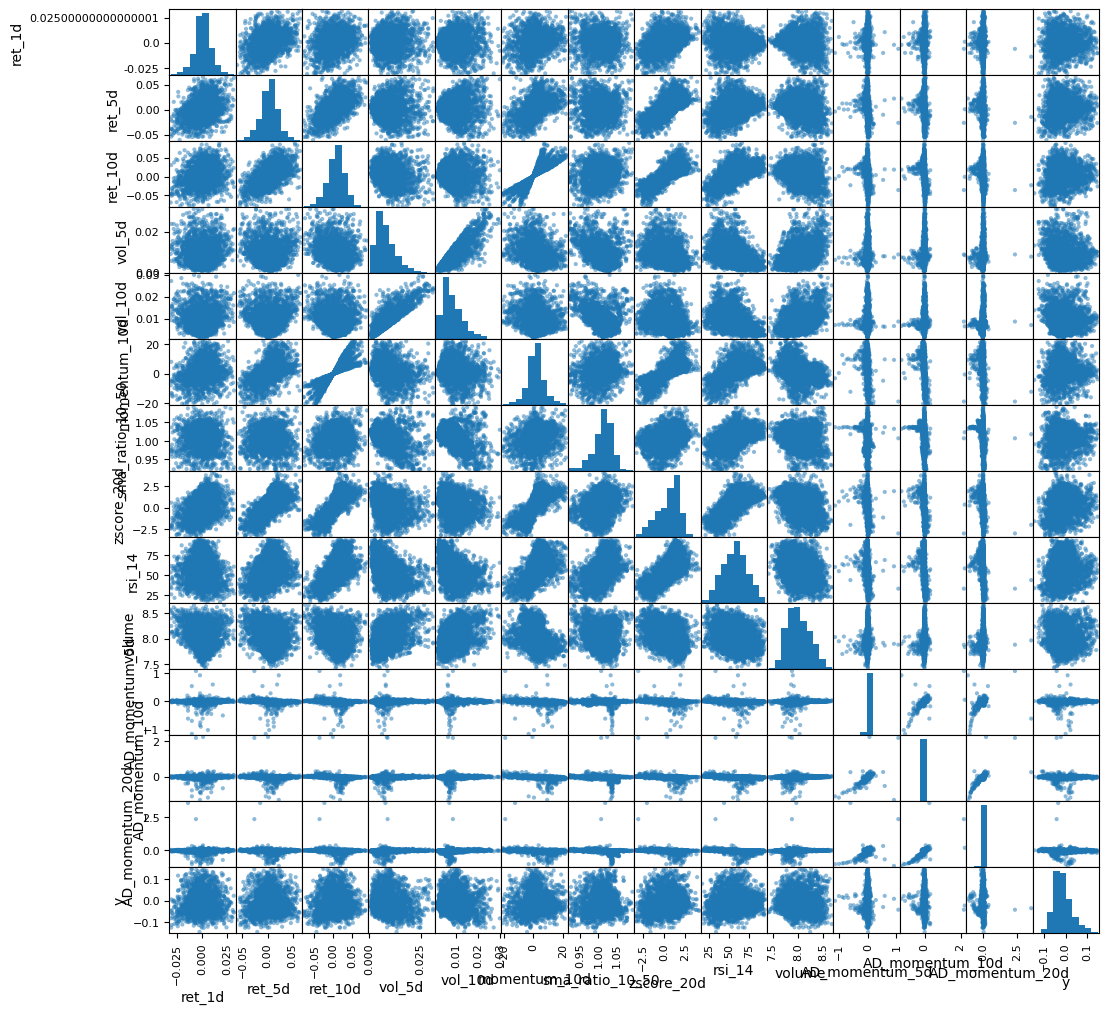

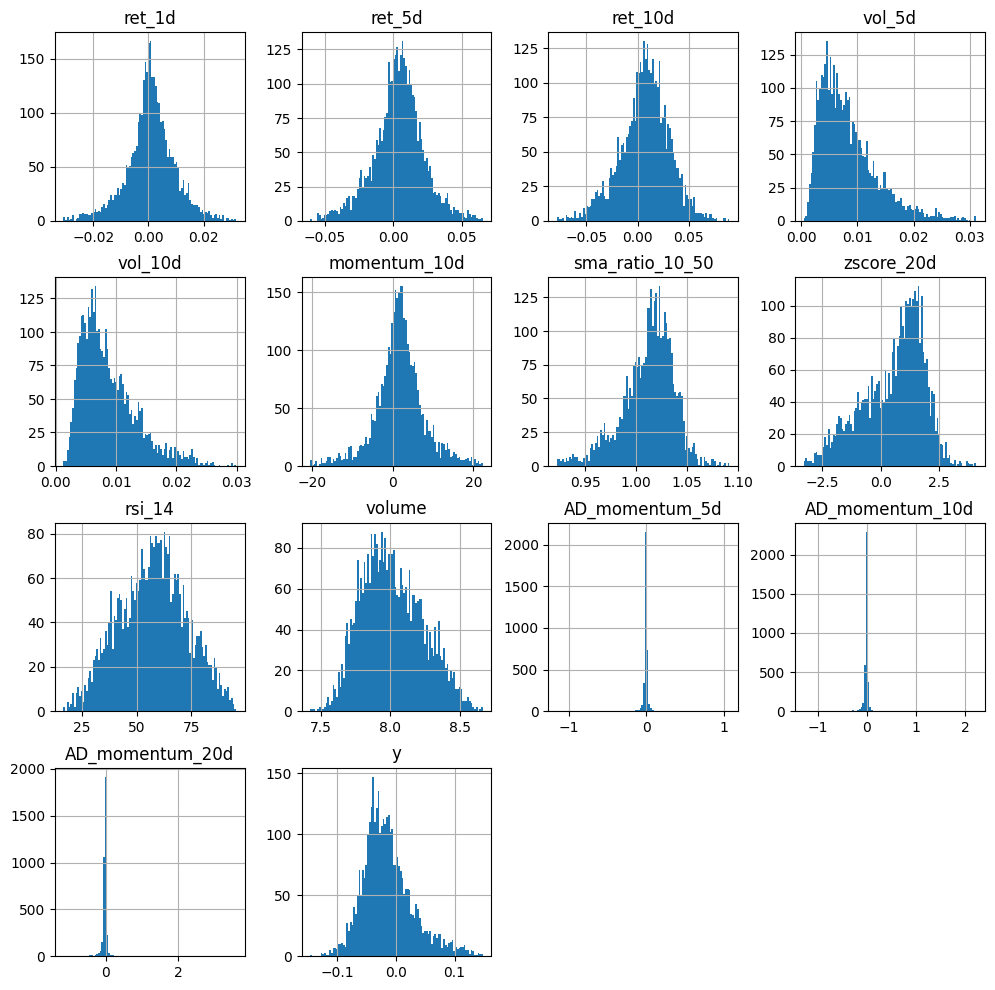

In [97]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Calculate Z-scores for the dataset
z_scores = np.abs(zscore(df_features_short_term))

# Set a threshold for identifying outliers (commonly 3)
threshold = 2.5 # confidence interval of data around 97.6 %.

# Identify rows where any column has a Z-score greater than threshold
outliers = (z_scores > threshold).any(axis=1)

# Remove outliers
df_no_outliers = df_features_short_term[~outliers]

# DATA ANALYSIS
from pandas.plotting import scatter_matrix

scatter_matrix(df_no_outliers, figsize=(12, 12), diagonal='hist')  # or 'kde'
df_no_outliers.hist(figsize=(12, 12), bins=100)

X_data = df_no_outliers.drop(columns=['y'])
y = df_no_outliers['y']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_data)
X_scaled = scaler.transform(X_data)
X = pd.DataFrame(X_scaled, index=X_data.index, columns=X_data.columns)


with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [98]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error 

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Sample time series data
# Split data between test set and train

import pandas as pd

# Ensure Date column is datetime type and sort the data
def train_test_split(df, ratio=0.2):

    num_instances = df.shape[0]

    split_index = int(num_instances * (1 - ratio))
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]
    return (train_df,test_df)

X_train, X_test = train_test_split(X)
y_train, y_test = train_test_split(y)

def directional_mse_obj(preds, dtrain):
    labels = dtrain.get_label()
    residuals = preds - labels
    
    # Gradient of MSE = 2 * (pred - label)
    grad = 2 * residuals
    
    # Hessian of MSE = 2
    hess = 2 * np.ones_like(labels)
    
    # Identify wrong direction predictions
    wrong_direction = np.sign(preds) != np.sign(labels)
    
    # Penalty factor (e.g., double the penalty)
    penalty = 2.0
    
    # Apply penalty to grad and hess where direction is wrong
    grad[wrong_direction] *= penalty
    hess[wrong_direction] *= penalty
    
    return grad, hess


# Use Kfold validation to tune hyperparameters using the train dataset
X_train_arr = X_train.values
y_train_arr = y_train.values

tscv = TimeSeriesSplit(n_splits=5)

val_rmse_scores = []
for i, (train_index, val_index) in enumerate(tscv.split(X_train_arr)):
    print(f"Split {i+1}: Train {len(train_index)}, Test {len(val_index)}")

    X_train_i, X_val_i = X_train_arr[train_index], X_train_arr[val_index]
    y_train_i, y_val_i = y_train_arr[train_index], y_train_arr[val_index]

    model = xgb.XGBRegressor(n_estimators=1000, 
                             early_stopping_rounds=50, 
                             learning_rate=0.01,
                             object=directional_mse_obj)

    model.fit(
        X_train_i, y_train_i,
        eval_set=[(X_train_i,y_train_i),(X_val_i, y_val_i)],
        verbose=100
    )
    
    preds = model.predict(X_val_i)
    rmse = root_mean_squared_error(y_val_i, preds)
    val_rmse_scores.append(rmse)

# Have a metric for directional accuracy to evaluate the impact of different hyperparameters
print(val_rmse_scores)
final_rmse = np.mean(val_rmse_scores)
print(f"\nFinal average RMSE across all folds: {final_rmse:.4f}")



model = xgb.XGBRegressor(n_estimators=1000,early_stopping_rounds=50,learning_rate=0.01)

model.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=100) # not sure about this

final_pred = model.predict(X_test)

print(root_mean_squared_error(y_test, final_pred))


Split 1: Train 481, Test 479
[0]	validation_0-rmse:0.05785	validation_1-rmse:0.04597
[50]	validation_0-rmse:0.04777	validation_1-rmse:0.04769
Split 2: Train 960, Test 479
[0]	validation_0-rmse:0.05217	validation_1-rmse:0.03021
[50]	validation_0-rmse:0.04354	validation_1-rmse:0.03408
Split 3: Train 1439, Test 479
[0]	validation_0-rmse:0.04589	validation_1-rmse:0.04344
[100]	validation_0-rmse:0.03765	validation_1-rmse:0.04258
[139]	validation_0-rmse:0.03495	validation_1-rmse:0.04291
Split 4: Train 1918, Test 479
[0]	validation_0-rmse:0.04517	validation_1-rmse:0.02773
[49]	validation_0-rmse:0.04021	validation_1-rmse:0.02974
Split 5: Train 2397, Test 479
[0]	validation_0-rmse:0.04225	validation_1-rmse:0.04590
[49]	validation_0-rmse:0.03862	validation_1-rmse:0.04673
[0.045965677748205244, 0.030208754917580346, 0.04249990880318752, 0.02772659378017396, 0.04590215869676784]

Final average RMSE across all folds: 0.0385
[0]	validation_0-rmse:0.04601
[51]	validation_0-rmse:0.04717
0.046005352938

In [99]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, root_mean_squared_error
import numpy as np

def directional_mse_obj(preds, dtrain):
    labels = dtrain.get_label()
    residuals = preds - labels
    
    # Gradient of MSE = 2 * (pred - label)
    grad = 2 * residuals
    
    # Hessian of MSE = 2
    hess = 2 * np.ones_like(labels)
    
    # Identify wrong direction predictions
    wrong_direction = np.sign(preds) != np.sign(labels)
    
    # Penalty factor (e.g., double the penalty)
    penalty = 2.0
    
    # Apply penalty to grad and hess where direction is wrong
    grad[wrong_direction] *= penalty
    hess[wrong_direction] *= penalty
    
    return grad, hess

# Define your parameter grid
param_grid = {
    'max_depth': [ 4, 5,6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300,500, 1000],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.4,0.6, 0.8],
    'reg_lambda': [0, 1, 10]  # L2 regularization
}
# Custom RMSE scorer
rmse_scorer = make_scorer(root_mean_squared_error)

# TimeSeries cross-validator
tscv = TimeSeriesSplit(n_splits=5)

# Model
xgb = XGBRegressor(verbosity=1,object=directional_mse_obj)

# Grid search
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1
)
print(y_train_arr)
# Fit
grid.fit(X_train_arr, y_train_arr)

# Results
print("Best parameters:", grid.best_params_)
print("Best CV RMSE:", grid.best_score_)

# Test set evaluation
y_pred = grid.best_estimator_.predict(X_test)
test_rmse = root_mean_squared_error(y_test, y_pred)
print("Test RMSE:", test_rmse)

[-0.0503181  -0.05694842 -0.07750935 ... -0.04591366 -0.04926928
 -0.05259271]
Fitting 5 folds for each of 729 candidates, totalling 3645 fits


KeyboardInterrupt: 

<Axes: title={'center': 'Feature Importance'}>

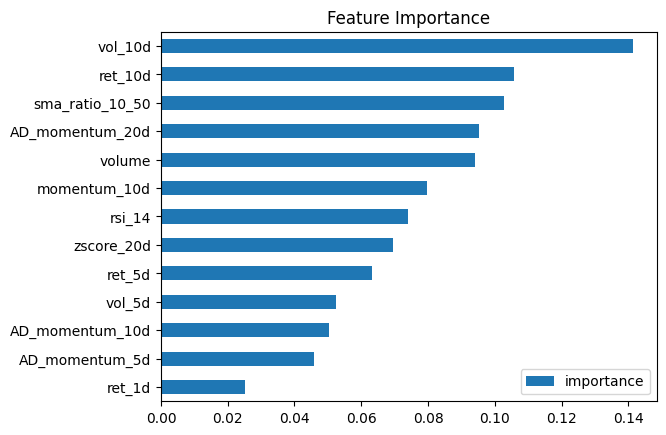

In [100]:
#model = grid.best_estimator_
fi = pd.DataFrame(data = model.feature_importances_,index=model.feature_names_in_,columns=['importance'])
fi.sort_values('importance').plot(kind='barh',title='Feature Importance')


0.036507084440344166
0.6773296244784422
0.7426981919332406


<Axes: >

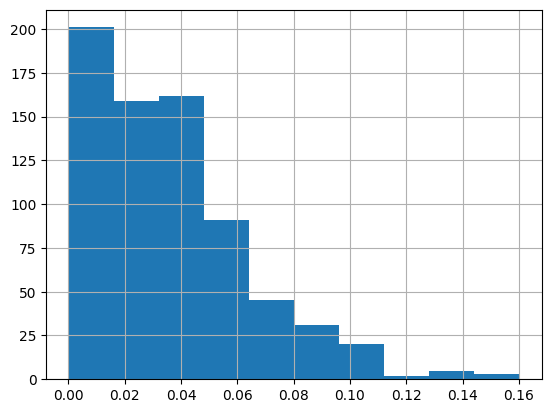

In [101]:
y_pred = model.predict(X_test)
pd.set_option('display.max_rows', None)
result = pd.DataFrame()
result['y'] = y_test
result['y_pred'] = y_pred
result['diff'] = abs((y_test-y_pred))
result['sign'] = np.sign(result['y']) == np.sign(result['y_pred'])
result['2diff'] = abs((y_test-y_pred)) < 0.05

same_sign = (result['sign']).sum()
small_diff = (result['2diff']).sum()
print(result['diff'].mean())
print(same_sign/len(y_pred))
print(small_diff/len(y_pred))
diff_ = result['diff'] 
diff_.hist()

In [102]:
model.save_model("xgb_model_SPY_0.0365_sorted.json") 
print(result.shape[0])

719
